In [142]:
import pandas as pd
import numpy as np
from dateutil import parser
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

Project: Educational Facilities in Nigeria, Data Cleaning, EDA & Interactive Dashboard

Dataset Overview

You are provided with a dataset containing information on 98,667 educational facilities across Nigeria, with 28 columns covering:

School identity and type
Water and sanitation facilities
Teacher and student population
Electricity access
Geographic location (latitude & longitude)
Management type and sector
Survey and community information


Your task is to clean the dataset, explore it using Exploratory Data Analysis (EDA), visualize key insights, and build an interactive dashboard using Streamlit.

Dataset:
Download the  Educational Facilities in Nigeria dataset from Open Africa.

Part 1: Data Understanding & Inspection
1. Load the dataset using Pandas.
    
2. Display:
    The first 10 rows
    Dataset shape
    Column names and data types
    Summary statistics

3. Identify:
    Missing values
    Incorrect data types
    Inconsistent values (e.g., True/False stored as text)

Part 2: Data Cleaning

Perform proper data cleaning using the following steps:

1. Handle Missing Values
    Decide whether to fill or drop missing values.
    Justify your choices.

2. Fix Data Types:
    Convert all applicable columns to their proper data types (e.g., object to boolean, object to datetime).

3. Drop Unnecessary Columns
    Remove columns that are not useful for analysis or visualization, such as:
        formhub_photo_id
        survey_id
        gps
        facility_id
 (You may drop more if justified.)

4. Validate Numeric Columns
    Ensure teacher, student, classroom, and toilet counts contain only valid numeric values.
    Remove or correct invalid entries.

5. Create at Least 3 New Features, such as:
    Student-to-teacher ratio
    Total teachers
    Total students
    Facility density by location



Part 3: Exploratory Data Analysis (EDA)
Answer the following key questions using analysis and supporting visualizations:

1. What are the most common types of educational facilities?
2. What percentage of schools have:
        Improved water supply?
        Improved sanitation?
        Electricity?

3. What is the average number of:
        Students per school?
        Teachers per school?

4. Compare public vs private schools in terms of:
        Student population
        Teacher count
        Infrastructure availability

5. Identify states or LGAs with:
        The highest number of schools
        The lowest access to electricity and sanitation

Part 4: Data Visualization
Create clear and well-labeled visualizations using Plotly. 
At minimum, include:

    Bar chart of school types
    Histogram of student population
    Boxplot of teacher distribution
    Pie chart of water and sanitation access
    Map visualization using latitude and longitude


Part 5: Interactive Dashboard with Streamlit
Build an interactive Streamlit dashboard that includes:

1. Dataset overview metrics
Display these five key performance indicators (KPI) at the top of the dashboard
        Total Number of Schools
        Total Number of Students
        Average Students per School
        Percentage of Schools with Electricity
        Percentage of Schools with Improved Water Supply


2. Interactive Filters

    Facility type
    Management (public/private)
    Location (state/LGA)

3. Dynamic Visualizations

Your dashboard must contain six interactive visualizations, such as:
    1. Bar Chart – Distribution of school types
    2. Histogram – Student population distribution
    3. Bar Chart – Public vs Private school comparison
    4. Pie Chart – Electricity availability
    5. Pie Chart – Water and sanitation access
    6. Map Visualization – School locations using latitude & longitude

4. Additional Features
        Download filtered data
        Sidebar controls



Part 6: Final Insights & Recommendations
Write a short report answering:
What major problems exist in Nigeria’s educational infrastructure?


Which regions need the most attention?


How can governments or NGOs use this data for decision-making?



In [143]:
# Part 1: Data Understanding & Inspection
# Load the dataset using Pandas.

df = pd.read_csv("data/educational_facilities_in_nigeria.csv")

df.head(2)



C:\Users\hp\AppData\Local\Temp\ipykernel_19120\1500908166.py:4: DtypeWarning: Columns (0: improved_water_supply, 1: improved_sanitation, 2: phcn_electricity) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("data/educational_facilities_in_nigeria.csv")


,facility_name,facility_type_display,improved_water_supply,improved_sanitation,chalkboard_each_classroom_yn,num_tchrs_with_nce,num_tchr_full_time,num_students_total,num_classrms_total,phcn_electricity,...,community,ward,management,sector,formhub_photo_id,gps,survey_id,unique_lga,latitude,longitude
0,CPS SWALI,Primary school only,True,True,False,9.0,9.0,776.0,12.0,False,...,Swali,3,public,education,1393404015008.jpg,4.91691036 6.27412844 31.5 5.0,51885096-65a1-4f1f-8c2a-3b11d9ae40bb,bayelsa_yenagoa,4.916910,6.274128
1,NANA Basic Academy,Primary and Junior Secondary school combined,False,False,NaN,NaN,NaN,NaN,NaN,False,...,Mpape,Dutse,private,education,1396960914896.jpg,9.140918333333333 7.496761666666667 697.0 4.5,7f3ea41a-e4cb-41dd-85fc-5fa54c42d09f,fct_bwari,9.140918,7.496762


In [144]:
# Part 1: Data Understanding & Inspection
# Display:
# The first 10 rows

df.head(10)



,facility_name,facility_type_display,improved_water_supply,improved_sanitation,chalkboard_each_classroom_yn,num_tchrs_with_nce,num_tchr_full_time,num_students_total,num_classrms_total,phcn_electricity,...,community,ward,management,sector,formhub_photo_id,gps,survey_id,unique_lga,latitude,longitude
0,CPS SWALI,Primary school only,True,True,False,9.0,9.0,776.0,12.0,False,...,Swali,3,public,education,1393404015008.jpg,4.91691036 6.27412844 31.5 5.0,51885096-65a1-4f1f-8c2a-3b11d9ae40bb,bayelsa_yenagoa,4.916910,6.274128
1,NANA Basic Academy,Primary and Junior Secondary school combined,False,False,NaN,NaN,NaN,NaN,NaN,False,...,Mpape,Dutse,private,education,1396960914896.jpg,9.140918333333333 7.496761666666667 697.0 4.5,7f3ea41a-e4cb-41dd-85fc-5fa54c42d09f,fct_bwari,9.140918,7.496762
2,L.E.A Primary School Pabeyi,Primary school only,True,True,False,9.0,11.0,283.0,9.0,False,...,Pabeyi,Dobi,public,education,1397575395444.jpg,9.174855 7.0220616666666675 236.8 5.0,56f2e625-ec43-4c39-97a8-d6379dceefa2,fct_gwagwalada,9.174855,7.022062
3,L.E.A.PrimarySchoolPagadna,Primary school only,False,True,False,4.0,5.0,247.0,7.0,False,...,Pagadna,Dobi,public,education,1398262573409.jpg,9.115846666666666 6.962314999999999 216.5 4.4,2932eda8-64b1-4068-8412-3b2e099062fc,fct_gwagwalada,9.115847,6.962315
4,Syflora Academy,Primary school only,False,True,True,4.0,8.0,66.0,10.0,True,...,Mpape,Dutse,private,education,1396959110576.jpg,9.141155 7.499665000000001 693.2 4.7,e17acb1e-364a-4a90-9384-0d612bb240c5,fct_bwari,9.141155,7.499665
5,Nomadic Paiko Kore,Primary school only,True,True,True,4.0,6.0,120.0,6.0,False,...,Paiko Kore,Paiko,public,education,1398330459520.jpg,8.99146 7.0096750000000005 170.9 5.0,28d8fe5a-7a18-4d17-9f64-7ae095eb1c50,fct_gwagwalada,8.991460,7.009675
6,Nomadic Jayi,Primary school only,True,True,True,4.0,4.0,152.0,9.0,False,...,Jayi,Dobi,public,education,1397572115063.jpg,9.204203333333334 7.015148333333333 271.4 4.5,31381276-73f9-4e30-acde-bec286919256,fct_gwagwalada,9.204203,7.015148
7,Nomadic Kutunku,Primary school only,True,True,False,7.0,10.0,245.0,10.0,True,...,Kutunku,Kutunku,public,education,1398345111978.jpg,8.934686666666666 7.056360000000001 174.9 4.6,76a5fbc9-6723-467a-939d-703a3702ec53,fct_gwagwalada,8.934687,7.056360
8,Bargada Primary School,Primary school only,False,True,False,4.0,5.0,181.0,10.0,False,...,Bargada,Paiko,public,education,1398340786686.jpg,8.921268333333334 6.959628333333335 161.8 4.3,6bd36fb3-704a-49ad-a96a-b25b24af78d3,fct_gwagwalada,8.921268,6.959628
9,Macbeth Intl School,Primary and Junior Secondary school combined,True,True,True,3.0,6.0,80.0,6.0,False,...,Byazhin,Byazhin,private,education,1397485980654.jpg,9.19196 7.3325966666666655 455.2 3.8,7e344ad8-c442-4138-a869-6ce98794beaa,fct_bwari,9.191960,7.332597


In [145]:
# Part 1: Data Understanding & Inspection
# Display:
# Dataset shape

df.shape




(98667, 28)

In [146]:
# Part 1: Data Understanding & Inspection
# Display:
# Column names and data types

df.info()


<class 'pandas.DataFrame'>
RangeIndex: 98667 entries, 0 to 98666
Data columns (total 28 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   facility_name                 98452 non-null  str    
 1   facility_type_display         97764 non-null  str    
 2   improved_water_supply         98388 non-null  object 
 3   improved_sanitation           98370 non-null  object 
 4   chalkboard_each_classroom_yn  96506 non-null  object 
 5   num_tchrs_with_nce            95137 non-null  float64
 6   num_tchr_full_time            96503 non-null  float64
 7   num_students_total            93405 non-null  float64
 8   num_classrms_total            95375 non-null  float64
 9   phcn_electricity              98390 non-null  object 
 10  num_toilets_total             95705 non-null  float64
 11  num_students_male             94292 non-null  float64
 12  num_students_female           94321 non-null  float64
 13  num_tchrs_ma

In [147]:
df.rename(columns={
   "facility_name" : "Facility_Name",
    "facility_type_display" : "Facility_Display_Type",
    "improved_water_supply" : "Improved_Water_Supply",
    "improved_sanitation" : "Improved_Sanitation",
    "chalkboard_each_classroom_yn" : "Chalkboard_Each_Classroom_yn",
    "num_tchrs_with_nce" : "Num_Teachers_With_Nce",
    "num_tchr_full_time" : "Num_Fulltime_Teachers",
    "num_students_total" : "Total_Students_Number",
    "num_classrms_total" : "Total_Classroom_Number",
    "phcn_electricity" : "PHCN_Electricity",
    "num_toilets_total" : "Number_Total_Toilets",
    "num_students_male" : "Number_Male_Students",
    "num_students_female" : "Number_Female_Student", 
    "num_tchrs_male": "Num_Male_Teachers",
    "num_tchrs_female": "Num_Female_Teachers",
    "date_of_survey" : "Date_Of_Survey",
    "education_type" : "Education_Type",
    "community" : "Community",
    "ward" : "Ward", 
    "management" : "Management", 
    "sector" : "Sector",
    "unique_lga" : "Unique_LGA",
    "latitude" : "Latitude",
    "longitude" : "Longitude"
}, inplace=True)

df.head(2)

,Facility_Name,Facility_Display_Type,Improved_Water_Supply,Improved_Sanitation,Chalkboard_Each_Classroom_yn,Num_Teachers_With_Nce,Num_Fulltime_Teachers,Total_Students_Number,Total_Classroom_Number,PHCN_Electricity,...,Community,Ward,Management,Sector,formhub_photo_id,gps,survey_id,Unique_LGA,Latitude,Longitude
0,CPS SWALI,Primary school only,True,True,False,9.0,9.0,776.0,12.0,False,...,Swali,3,public,education,1393404015008.jpg,4.91691036 6.27412844 31.5 5.0,51885096-65a1-4f1f-8c2a-3b11d9ae40bb,bayelsa_yenagoa,4.916910,6.274128
1,NANA Basic Academy,Primary and Junior Secondary school combined,False,False,NaN,NaN,NaN,NaN,NaN,False,...,Mpape,Dutse,private,education,1396960914896.jpg,9.140918333333333 7.496761666666667 697.0 4.5,7f3ea41a-e4cb-41dd-85fc-5fa54c42d09f,fct_bwari,9.140918,7.496762


In [148]:
# Part 1: Data Understanding & Inspection
# Display:
# data types


df.dtypes


Facility_Name                       str
Facility_Display_Type               str
Improved_Water_Supply            object
Improved_Sanitation              object
Chalkboard_Each_Classroom_yn     object
Num_Teachers_With_Nce           float64
Num_Fulltime_Teachers           float64
Total_Students_Number           float64
Total_Classroom_Number          float64
PHCN_Electricity                 object
Number_Total_Toilets            float64
Number_Male_Students            float64
Number_Female_Student           float64
Num_Male_Teachers               float64
Num_Female_Teachers             float64
Date_Of_Survey                      str
Education_Type                      str
facility_id                         str
Community                           str
Ward                                str
Management                          str
Sector                              str
formhub_photo_id                    str
gps                                 str
survey_id                           str


In [149]:
#Part 1: Data Understanding & Inspection
# Display:
# Summary statistics

df.describe()




,Num_Teachers_With_Nce,Num_Fulltime_Teachers,Total_Students_Number,Total_Classroom_Number,Number_Total_Toilets,Number_Male_Students,Number_Female_Student,Num_Male_Teachers,Num_Female_Teachers,Latitude,Longitude
count,95137.000000,96503.000000,93405.000000,95375.000000,95705.000000,94292.000000,94321.000000,94987.000000,95348.000000,98667.000000,98667.000000
mean,7.017922,11.666197,335.406306,8.443512,2.546722,187.804628,169.837438,5.723583,5.957985,8.636626,7.183757
std,8.045479,14.033793,343.354223,7.110507,5.768857,257.891030,227.880995,6.205914,8.519480,2.403356,2.353375
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,4.280918,2.707594
25%,2.000000,4.000000,118.000000,4.000000,0.000000,59.000000,50.000000,2.000000,0.000000,6.671873,5.327685
50%,5.000000,8.000000,223.000000,6.000000,0.000000,114.000000,100.000000,4.000000,3.000000,8.140478,7.303945
75%,9.000000,14.000000,419.000000,11.000000,4.000000,220.000000,200.000000,7.000000,8.000000,10.631606,8.566094
max,100.000000,899.000000,2355.000000,514.000000,418.000000,7677.000000,6689.000000,100.000000,100.000000,13.875585,14.636391


In [150]:
# Part 1: Data Understanding & Inspection
# Identify:
# Missing values

df.isnull().sum().sort_values(ascending=False)




Total_Students_Number           5262
Number_Male_Students            4375
Number_Female_Student           4346
Num_Male_Teachers               3680
Num_Teachers_With_Nce           3530
Num_Female_Teachers             3319
Total_Classroom_Number          3292
Number_Total_Toilets            2962
Num_Fulltime_Teachers           2164
Chalkboard_Each_Classroom_yn    2161
Management                      1223
Facility_Display_Type            903
Ward                             771
Improved_Sanitation              297
Improved_Water_Supply            279
PHCN_Electricity                 277
Community                        238
Education_Type                   221
Facility_Name                    215
Unique_LGA                         1
facility_id                        0
Date_Of_Survey                     0
formhub_photo_id                   0
Sector                             0
gps                                0
survey_id                          0
Latitude                           0
L

In [151]:
# Part 1: Data Understanding & Inspection
# Identify:
# Incorrect data types

#df.info()

df.dtypes



Facility_Name                       str
Facility_Display_Type               str
Improved_Water_Supply            object
Improved_Sanitation              object
Chalkboard_Each_Classroom_yn     object
Num_Teachers_With_Nce           float64
Num_Fulltime_Teachers           float64
Total_Students_Number           float64
Total_Classroom_Number          float64
PHCN_Electricity                 object
Number_Total_Toilets            float64
Number_Male_Students            float64
Number_Female_Student           float64
Num_Male_Teachers               float64
Num_Female_Teachers             float64
Date_Of_Survey                      str
Education_Type                      str
facility_id                         str
Community                           str
Ward                                str
Management                          str
Sector                              str
formhub_photo_id                    str
gps                                 str
survey_id                           str


In [152]:
# Part 1: Data Understanding & Inspection
# Display:
# Inconsistent values (e.g., True/False stored as text)

for col in df.columns: 
    print(col)
    print(df[col].unique()[:15])

    # for col in df.select_dtypes(include='object'):
    # print(f"\n{col}")
    # print(df[col].value_counts().head(20))



Facility_Name
<ArrowStringArray>
[                                   'CPS SWALI',
                           'NANA Basic Academy',
                  'L.E.A Primary School Pabeyi',
                   'L.E.A.PrimarySchoolPagadna',
                              'Syflora Academy',
                           'Nomadic Paiko Kore',
                                 'Nomadic Jayi',
                              'Nomadic Kutunku',
                       'Bargada Primary School',
                          'Macbeth Intl School',
                             'Kel Rose Academy',
 'Ideal Nursery/Primary/Junior Secodary School',
                          'Golden Hope Academy',
                         'Fely Ben Intl School',
                        'Divine Wisdom Academy']
Length: 15, dtype: str
Facility_Display_Type
<ArrowStringArray>
[                                 'Primary school only',
         'Primary and Junior Secondary school combined',
 'Primary, Junior and Senior Secondary school combined

In [153]:
# Part 2: Data Cleaning
# Perform proper data cleaning using the following steps:
# 1. Handle Missing Values
#     Decide whether to fill or drop missing values.
#    Justify your choices.
# Numerical colunms 

num_cols = df.select_dtypes(include=['int64','float64']).columns

for col in num_cols:
    df[col] = df[col].fillna(df[col].median())

df

    

,Facility_Name,Facility_Display_Type,Improved_Water_Supply,Improved_Sanitation,Chalkboard_Each_Classroom_yn,Num_Teachers_With_Nce,Num_Fulltime_Teachers,Total_Students_Number,Total_Classroom_Number,PHCN_Electricity,...,Community,Ward,Management,Sector,formhub_photo_id,gps,survey_id,Unique_LGA,Latitude,Longitude
0,CPS SWALI,Primary school only,True,True,False,9.0,9.0,776.0,12.0,False,...,Swali,3,public,education,1393404015008.jpg,4.91691036 6.27412844 31.5 5.0,51885096-65a1-4f1f-8c2a-3b11d9ae40bb,bayelsa_yenagoa,4.916910,6.274128
1,NANA Basic Academy,Primary and Junior Secondary school combined,False,False,NaN,5.0,8.0,223.0,6.0,False,...,Mpape,Dutse,private,education,1396960914896.jpg,9.140918333333333 7.496761666666667 697.0 4.5,7f3ea41a-e4cb-41dd-85fc-5fa54c42d09f,fct_bwari,9.140918,7.496762
2,L.E.A Primary School Pabeyi,Primary school only,True,True,False,9.0,11.0,283.0,9.0,False,...,Pabeyi,Dobi,public,education,1397575395444.jpg,9.174855 7.0220616666666675 236.8 5.0,56f2e625-ec43-4c39-97a8-d6379dceefa2,fct_gwagwalada,9.174855,7.022062
3,L.E.A.PrimarySchoolPagadna,Primary school only,False,True,False,4.0,5.0,247.0,7.0,False,...,Pagadna,Dobi,public,education,1398262573409.jpg,9.115846666666666 6.962314999999999 216.5 4.4,2932eda8-64b1-4068-8412-3b2e099062fc,fct_gwagwalada,9.115847,6.962315
4,Syflora Academy,Primary school only,False,True,True,4.0,8.0,66.0,10.0,True,...,Mpape,Dutse,private,education,1396959110576.jpg,9.141155 7.499665000000001 693.2 4.7,e17acb1e-364a-4a90-9384-0d612bb240c5,fct_bwari,9.141155,7.499665
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
98662,Liberty Primary School,Pre-primary and Primary school combined,True,True,True,10.0,11.0,449.0,9.0,False,...,Atan,Atan,private,education,1396871679634.jpg,6.66737138 3.09158342 74.0 5.0,010545d1-8fed-41fe-bcae-c142046a04e3,ogun_ado_odo_ota,6.667371,3.091583
98663,Anfani Primary School,Primary school only,True,True,False,8.0,9.0,253.0,8.0,False,...,Anfani,Nasarawa,public,education,1396966652017.jpg,9.924088236017527 4.634761001792765 192.104372...,5d81b15f-a114-4987-adce-70b67744f3ad,niger_magama,9.924088,4.634761
98664,OLUMAWU BASIC SCHOOL,Pre-primary and Primary school combined,True,True,True,77.0,77.0,567.0,40.0,True,...,WUSE 2,WUSE II,private,education,1398257399697.jpg,9.071785 7.477803333333332 474.9 5.0,6d63ceb8-bca5-4702-8313-41944e2d2dbd,fct_municipal_area_council,9.071785,7.477803
98665,UBE Akudu Karreh,Pre-primary and Primary school combined,False,False,False,3.0,10.0,330.0,6.0,False,...,Akudu Akarreh,Karreh,public,education,1394973132370.jpg,10.77455242 8.36796434 744.0 81.0,e22ff822-bf51-4a22-81b8-32ba8642b0f7,kaduna_kubau,10.774552,8.367964


In [154]:
# Part 2: Data Cleaning
# Perform proper data cleaning using the following steps:
# 1. Handle Missing Values
#     Decide whether to fill or drop missing values.
#    Justify your choices.
# Categories colunms 

cat_cols = df.select_dtypes(include='object').columns

for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])
    
df


C:\Users\hp\AppData\Local\Temp\ipykernel_19120\204258006.py:8: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include='object').columns


,Facility_Name,Facility_Display_Type,Improved_Water_Supply,Improved_Sanitation,Chalkboard_Each_Classroom_yn,Num_Teachers_With_Nce,Num_Fulltime_Teachers,Total_Students_Number,Total_Classroom_Number,PHCN_Electricity,...,Community,Ward,Management,Sector,formhub_photo_id,gps,survey_id,Unique_LGA,Latitude,Longitude
0,CPS SWALI,Primary school only,True,True,False,9.0,9.0,776.0,12.0,False,...,Swali,3,public,education,1393404015008.jpg,4.91691036 6.27412844 31.5 5.0,51885096-65a1-4f1f-8c2a-3b11d9ae40bb,bayelsa_yenagoa,4.916910,6.274128
1,NANA Basic Academy,Primary and Junior Secondary school combined,False,False,False,5.0,8.0,223.0,6.0,False,...,Mpape,Dutse,private,education,1396960914896.jpg,9.140918333333333 7.496761666666667 697.0 4.5,7f3ea41a-e4cb-41dd-85fc-5fa54c42d09f,fct_bwari,9.140918,7.496762
2,L.E.A Primary School Pabeyi,Primary school only,True,True,False,9.0,11.0,283.0,9.0,False,...,Pabeyi,Dobi,public,education,1397575395444.jpg,9.174855 7.0220616666666675 236.8 5.0,56f2e625-ec43-4c39-97a8-d6379dceefa2,fct_gwagwalada,9.174855,7.022062
3,L.E.A.PrimarySchoolPagadna,Primary school only,False,True,False,4.0,5.0,247.0,7.0,False,...,Pagadna,Dobi,public,education,1398262573409.jpg,9.115846666666666 6.962314999999999 216.5 4.4,2932eda8-64b1-4068-8412-3b2e099062fc,fct_gwagwalada,9.115847,6.962315
4,Syflora Academy,Primary school only,False,True,True,4.0,8.0,66.0,10.0,True,...,Mpape,Dutse,private,education,1396959110576.jpg,9.141155 7.499665000000001 693.2 4.7,e17acb1e-364a-4a90-9384-0d612bb240c5,fct_bwari,9.141155,7.499665
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
98662,Liberty Primary School,Pre-primary and Primary school combined,True,True,True,10.0,11.0,449.0,9.0,False,...,Atan,Atan,private,education,1396871679634.jpg,6.66737138 3.09158342 74.0 5.0,010545d1-8fed-41fe-bcae-c142046a04e3,ogun_ado_odo_ota,6.667371,3.091583
98663,Anfani Primary School,Primary school only,True,True,False,8.0,9.0,253.0,8.0,False,...,Anfani,Nasarawa,public,education,1396966652017.jpg,9.924088236017527 4.634761001792765 192.104372...,5d81b15f-a114-4987-adce-70b67744f3ad,niger_magama,9.924088,4.634761
98664,OLUMAWU BASIC SCHOOL,Pre-primary and Primary school combined,True,True,True,77.0,77.0,567.0,40.0,True,...,WUSE 2,WUSE II,private,education,1398257399697.jpg,9.071785 7.477803333333332 474.9 5.0,6d63ceb8-bca5-4702-8313-41944e2d2dbd,fct_municipal_area_council,9.071785,7.477803
98665,UBE Akudu Karreh,Pre-primary and Primary school combined,False,False,False,3.0,10.0,330.0,6.0,False,...,Akudu Akarreh,Karreh,public,education,1394973132370.jpg,10.77455242 8.36796434 744.0 81.0,e22ff822-bf51-4a22-81b8-32ba8642b0f7,kaduna_kubau,10.774552,8.367964


In [155]:
# Part 2: Data Cleaning

# Perform proper data cleaning using the following steps:
# 2. Fix Data Types:
#     Convert all applicable columns to their proper data types (e.g., object to boolean, object to datetime).

bool_cols = [
    "Improved_Water_Supply",
    "Improved_Sanitation",
    "Chalkboard_Each_Classroom_yn",
    "PHCN_Electricity"    
]

for col in bool_cols:
    df[col] = df[col].astype(bool)

df

,Facility_Name,Facility_Display_Type,Improved_Water_Supply,Improved_Sanitation,Chalkboard_Each_Classroom_yn,Num_Teachers_With_Nce,Num_Fulltime_Teachers,Total_Students_Number,Total_Classroom_Number,PHCN_Electricity,...,Community,Ward,Management,Sector,formhub_photo_id,gps,survey_id,Unique_LGA,Latitude,Longitude
0,CPS SWALI,Primary school only,True,True,False,9.0,9.0,776.0,12.0,False,...,Swali,3,public,education,1393404015008.jpg,4.91691036 6.27412844 31.5 5.0,51885096-65a1-4f1f-8c2a-3b11d9ae40bb,bayelsa_yenagoa,4.916910,6.274128
1,NANA Basic Academy,Primary and Junior Secondary school combined,False,False,False,5.0,8.0,223.0,6.0,False,...,Mpape,Dutse,private,education,1396960914896.jpg,9.140918333333333 7.496761666666667 697.0 4.5,7f3ea41a-e4cb-41dd-85fc-5fa54c42d09f,fct_bwari,9.140918,7.496762
2,L.E.A Primary School Pabeyi,Primary school only,True,True,False,9.0,11.0,283.0,9.0,False,...,Pabeyi,Dobi,public,education,1397575395444.jpg,9.174855 7.0220616666666675 236.8 5.0,56f2e625-ec43-4c39-97a8-d6379dceefa2,fct_gwagwalada,9.174855,7.022062
3,L.E.A.PrimarySchoolPagadna,Primary school only,False,True,False,4.0,5.0,247.0,7.0,False,...,Pagadna,Dobi,public,education,1398262573409.jpg,9.115846666666666 6.962314999999999 216.5 4.4,2932eda8-64b1-4068-8412-3b2e099062fc,fct_gwagwalada,9.115847,6.962315
4,Syflora Academy,Primary school only,False,True,True,4.0,8.0,66.0,10.0,True,...,Mpape,Dutse,private,education,1396959110576.jpg,9.141155 7.499665000000001 693.2 4.7,e17acb1e-364a-4a90-9384-0d612bb240c5,fct_bwari,9.141155,7.499665
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
98662,Liberty Primary School,Pre-primary and Primary school combined,True,True,True,10.0,11.0,449.0,9.0,False,...,Atan,Atan,private,education,1396871679634.jpg,6.66737138 3.09158342 74.0 5.0,010545d1-8fed-41fe-bcae-c142046a04e3,ogun_ado_odo_ota,6.667371,3.091583
98663,Anfani Primary School,Primary school only,True,True,False,8.0,9.0,253.0,8.0,False,...,Anfani,Nasarawa,public,education,1396966652017.jpg,9.924088236017527 4.634761001792765 192.104372...,5d81b15f-a114-4987-adce-70b67744f3ad,niger_magama,9.924088,4.634761
98664,OLUMAWU BASIC SCHOOL,Pre-primary and Primary school combined,True,True,True,77.0,77.0,567.0,40.0,True,...,WUSE 2,WUSE II,private,education,1398257399697.jpg,9.071785 7.477803333333332 474.9 5.0,6d63ceb8-bca5-4702-8313-41944e2d2dbd,fct_municipal_area_council,9.071785,7.477803
98665,UBE Akudu Karreh,Pre-primary and Primary school combined,False,False,False,3.0,10.0,330.0,6.0,False,...,Akudu Akarreh,Karreh,public,education,1394973132370.jpg,10.77455242 8.36796434 744.0 81.0,e22ff822-bf51-4a22-81b8-32ba8642b0f7,kaduna_kubau,10.774552,8.367964


In [156]:
# Part 2: Data Cleaning

# Perform proper data cleaning using the following steps:
# 2. Fix Data Types:
#     Convert all applicable columns to their proper data types (e.g., object to boolean, object to datetime).

numeric_cols = [
    "Num_Teachers_With_Nce",
    "Num_Fulltime_Teachers",
    "Total_Students_Number",
    "Total_Classroom_Number",
    "Number_Total_Toilets",
    "Number_Male_Students",
    "Number_Female_Student",
    "Num_Male_Teachers",
    "Num_Female_Teachers"
]

for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

df

,Facility_Name,Facility_Display_Type,Improved_Water_Supply,Improved_Sanitation,Chalkboard_Each_Classroom_yn,Num_Teachers_With_Nce,Num_Fulltime_Teachers,Total_Students_Number,Total_Classroom_Number,PHCN_Electricity,...,Community,Ward,Management,Sector,formhub_photo_id,gps,survey_id,Unique_LGA,Latitude,Longitude
0,CPS SWALI,Primary school only,True,True,False,9.0,9.0,776.0,12.0,False,...,Swali,3,public,education,1393404015008.jpg,4.91691036 6.27412844 31.5 5.0,51885096-65a1-4f1f-8c2a-3b11d9ae40bb,bayelsa_yenagoa,4.916910,6.274128
1,NANA Basic Academy,Primary and Junior Secondary school combined,False,False,False,5.0,8.0,223.0,6.0,False,...,Mpape,Dutse,private,education,1396960914896.jpg,9.140918333333333 7.496761666666667 697.0 4.5,7f3ea41a-e4cb-41dd-85fc-5fa54c42d09f,fct_bwari,9.140918,7.496762
2,L.E.A Primary School Pabeyi,Primary school only,True,True,False,9.0,11.0,283.0,9.0,False,...,Pabeyi,Dobi,public,education,1397575395444.jpg,9.174855 7.0220616666666675 236.8 5.0,56f2e625-ec43-4c39-97a8-d6379dceefa2,fct_gwagwalada,9.174855,7.022062
3,L.E.A.PrimarySchoolPagadna,Primary school only,False,True,False,4.0,5.0,247.0,7.0,False,...,Pagadna,Dobi,public,education,1398262573409.jpg,9.115846666666666 6.962314999999999 216.5 4.4,2932eda8-64b1-4068-8412-3b2e099062fc,fct_gwagwalada,9.115847,6.962315
4,Syflora Academy,Primary school only,False,True,True,4.0,8.0,66.0,10.0,True,...,Mpape,Dutse,private,education,1396959110576.jpg,9.141155 7.499665000000001 693.2 4.7,e17acb1e-364a-4a90-9384-0d612bb240c5,fct_bwari,9.141155,7.499665
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
98662,Liberty Primary School,Pre-primary and Primary school combined,True,True,True,10.0,11.0,449.0,9.0,False,...,Atan,Atan,private,education,1396871679634.jpg,6.66737138 3.09158342 74.0 5.0,010545d1-8fed-41fe-bcae-c142046a04e3,ogun_ado_odo_ota,6.667371,3.091583
98663,Anfani Primary School,Primary school only,True,True,False,8.0,9.0,253.0,8.0,False,...,Anfani,Nasarawa,public,education,1396966652017.jpg,9.924088236017527 4.634761001792765 192.104372...,5d81b15f-a114-4987-adce-70b67744f3ad,niger_magama,9.924088,4.634761
98664,OLUMAWU BASIC SCHOOL,Pre-primary and Primary school combined,True,True,True,77.0,77.0,567.0,40.0,True,...,WUSE 2,WUSE II,private,education,1398257399697.jpg,9.071785 7.477803333333332 474.9 5.0,6d63ceb8-bca5-4702-8313-41944e2d2dbd,fct_municipal_area_council,9.071785,7.477803
98665,UBE Akudu Karreh,Pre-primary and Primary school combined,False,False,False,3.0,10.0,330.0,6.0,False,...,Akudu Akarreh,Karreh,public,education,1394973132370.jpg,10.77455242 8.36796434 744.0 81.0,e22ff822-bf51-4a22-81b8-32ba8642b0f7,kaduna_kubau,10.774552,8.367964


In [157]:
# Part 2: Data Cleaning

# Perform proper data cleaning using the following steps:
# 3. Drop Unnecessary Columns
#     Remove columns that are not useful for analysis or visualization, such as:
#         formhub_photo_id
#         survey_id
#         gps
#         facility_id
#  (You may drop more if justified.)

drop_cols = [
    
    "formhub_photo_id",
    "survey_id",
    "gps",
    "facility_id"
]

df.drop(columns=drop_cols, errors="ignore")

df.head(2)

,Facility_Name,Facility_Display_Type,Improved_Water_Supply,Improved_Sanitation,Chalkboard_Each_Classroom_yn,Num_Teachers_With_Nce,Num_Fulltime_Teachers,Total_Students_Number,Total_Classroom_Number,PHCN_Electricity,...,Community,Ward,Management,Sector,formhub_photo_id,gps,survey_id,Unique_LGA,Latitude,Longitude
0,CPS SWALI,Primary school only,True,True,False,9.0,9.0,776.0,12.0,False,...,Swali,3,public,education,1393404015008.jpg,4.91691036 6.27412844 31.5 5.0,51885096-65a1-4f1f-8c2a-3b11d9ae40bb,bayelsa_yenagoa,4.916910,6.274128
1,NANA Basic Academy,Primary and Junior Secondary school combined,False,False,False,5.0,8.0,223.0,6.0,False,...,Mpape,Dutse,private,education,1396960914896.jpg,9.140918333333333 7.496761666666667 697.0 4.5,7f3ea41a-e4cb-41dd-85fc-5fa54c42d09f,fct_bwari,9.140918,7.496762


In [158]:
# Part 2: Data Cleaning

# Perform proper data cleaning using the following steps:
# 4. Validate Numeric Columns
#     Ensure teacher, student, classroom, and toilet counts contain only valid numeric values.
#     Remove or correct invalid entries.

count_cols = [
    "Num_Teachers_With_Nce",
    "Num_Fulltime_Teachers",
    "Total_Students_Number",
    "Total_Classroom_Number",
    "Number_Total_Toilets",
    "Number_Male_Students",
    "Number_Female_Student",
    "Num_Male_Teachers",
    "Num_Female_Teachers"
]

for col in count_cols:
    df = df[df[col] >= 0]
    
df.head(2)


,Facility_Name,Facility_Display_Type,Improved_Water_Supply,Improved_Sanitation,Chalkboard_Each_Classroom_yn,Num_Teachers_With_Nce,Num_Fulltime_Teachers,Total_Students_Number,Total_Classroom_Number,PHCN_Electricity,...,Community,Ward,Management,Sector,formhub_photo_id,gps,survey_id,Unique_LGA,Latitude,Longitude
0,CPS SWALI,Primary school only,True,True,False,9.0,9.0,776.0,12.0,False,...,Swali,3,public,education,1393404015008.jpg,4.91691036 6.27412844 31.5 5.0,51885096-65a1-4f1f-8c2a-3b11d9ae40bb,bayelsa_yenagoa,4.916910,6.274128
1,NANA Basic Academy,Primary and Junior Secondary school combined,False,False,False,5.0,8.0,223.0,6.0,False,...,Mpape,Dutse,private,education,1396960914896.jpg,9.140918333333333 7.496761666666667 697.0 4.5,7f3ea41a-e4cb-41dd-85fc-5fa54c42d09f,fct_bwari,9.140918,7.496762


In [159]:
# Part 2: Data Cleaning

# Perform proper data cleaning using the following steps:
# 5. Create at Least 3 New Features, such as:
#     Student-to-teacher ratio
#     Total teachers
#     Total students
#     Facility density by location

In [160]:
# Part 2: Data Cleaning
# Perform proper data cleaning using the following steps:
# 5. Create at Least 3 New Features, such as:
#     Total students

df["Total_Students"] = (
    df["Number_Male_Students"]
    + df["Number_Female_Student"]
)

df.head(2)

,Facility_Name,Facility_Display_Type,Improved_Water_Supply,Improved_Sanitation,Chalkboard_Each_Classroom_yn,Num_Teachers_With_Nce,Num_Fulltime_Teachers,Total_Students_Number,Total_Classroom_Number,PHCN_Electricity,...,Ward,Management,Sector,formhub_photo_id,gps,survey_id,Unique_LGA,Latitude,Longitude,Total_Students
0,CPS SWALI,Primary school only,True,True,False,9.0,9.0,776.0,12.0,False,...,3,public,education,1393404015008.jpg,4.91691036 6.27412844 31.5 5.0,51885096-65a1-4f1f-8c2a-3b11d9ae40bb,bayelsa_yenagoa,4.916910,6.274128,776.0
1,NANA Basic Academy,Primary and Junior Secondary school combined,False,False,False,5.0,8.0,223.0,6.0,False,...,Dutse,private,education,1396960914896.jpg,9.140918333333333 7.496761666666667 697.0 4.5,7f3ea41a-e4cb-41dd-85fc-5fa54c42d09f,fct_bwari,9.140918,7.496762,214.0


In [161]:
# Part 2: Data Cleaning
# Perform proper data cleaning using the following steps:
# 5. Create at Least 3 New Features, such as:
# Total teachers

df["Total_Teachers"] = (
    df["Num_Male_Teachers"]
    + df["Num_Female_Teachers"]
)

df.head(2)

,Facility_Name,Facility_Display_Type,Improved_Water_Supply,Improved_Sanitation,Chalkboard_Each_Classroom_yn,Num_Teachers_With_Nce,Num_Fulltime_Teachers,Total_Students_Number,Total_Classroom_Number,PHCN_Electricity,...,Management,Sector,formhub_photo_id,gps,survey_id,Unique_LGA,Latitude,Longitude,Total_Students,Total_Teachers
0,CPS SWALI,Primary school only,True,True,False,9.0,9.0,776.0,12.0,False,...,public,education,1393404015008.jpg,4.91691036 6.27412844 31.5 5.0,51885096-65a1-4f1f-8c2a-3b11d9ae40bb,bayelsa_yenagoa,4.916910,6.274128,776.0,9.0
1,NANA Basic Academy,Primary and Junior Secondary school combined,False,False,False,5.0,8.0,223.0,6.0,False,...,private,education,1396960914896.jpg,9.140918333333333 7.496761666666667 697.0 4.5,7f3ea41a-e4cb-41dd-85fc-5fa54c42d09f,fct_bwari,9.140918,7.496762,214.0,7.0


In [162]:
# Perform proper data cleaning using the following steps:
# 5. Create at Least 3 New Features, such as:
#     Student-to-teacher ratio

df["Student_Teacher_Ratio"] = (
    df["Total_Students"]
    / df["Total_Teachers"]
)

df

,Facility_Name,Facility_Display_Type,Improved_Water_Supply,Improved_Sanitation,Chalkboard_Each_Classroom_yn,Num_Teachers_With_Nce,Num_Fulltime_Teachers,Total_Students_Number,Total_Classroom_Number,PHCN_Electricity,...,Sector,formhub_photo_id,gps,survey_id,Unique_LGA,Latitude,Longitude,Total_Students,Total_Teachers,Student_Teacher_Ratio
0,CPS SWALI,Primary school only,True,True,False,9.0,9.0,776.0,12.0,False,...,education,1393404015008.jpg,4.91691036 6.27412844 31.5 5.0,51885096-65a1-4f1f-8c2a-3b11d9ae40bb,bayelsa_yenagoa,4.916910,6.274128,776.0,9.0,86.222222
1,NANA Basic Academy,Primary and Junior Secondary school combined,False,False,False,5.0,8.0,223.0,6.0,False,...,education,1396960914896.jpg,9.140918333333333 7.496761666666667 697.0 4.5,7f3ea41a-e4cb-41dd-85fc-5fa54c42d09f,fct_bwari,9.140918,7.496762,214.0,7.0,30.571429
2,L.E.A Primary School Pabeyi,Primary school only,True,True,False,9.0,11.0,283.0,9.0,False,...,education,1397575395444.jpg,9.174855 7.0220616666666675 236.8 5.0,56f2e625-ec43-4c39-97a8-d6379dceefa2,fct_gwagwalada,9.174855,7.022062,283.0,11.0,25.727273
3,L.E.A.PrimarySchoolPagadna,Primary school only,False,True,False,4.0,5.0,247.0,7.0,False,...,education,1398262573409.jpg,9.115846666666666 6.962314999999999 216.5 4.4,2932eda8-64b1-4068-8412-3b2e099062fc,fct_gwagwalada,9.115847,6.962315,247.0,5.0,49.400000
4,Syflora Academy,Primary school only,False,True,True,4.0,8.0,66.0,10.0,True,...,education,1396959110576.jpg,9.141155 7.499665000000001 693.2 4.7,e17acb1e-364a-4a90-9384-0d612bb240c5,fct_bwari,9.141155,7.499665,66.0,8.0,8.250000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
98662,Liberty Primary School,Pre-primary and Primary school combined,True,True,True,10.0,11.0,449.0,9.0,False,...,education,1396871679634.jpg,6.66737138 3.09158342 74.0 5.0,010545d1-8fed-41fe-bcae-c142046a04e3,ogun_ado_odo_ota,6.667371,3.091583,449.0,11.0,40.818182
98663,Anfani Primary School,Primary school only,True,True,False,8.0,9.0,253.0,8.0,False,...,education,1396966652017.jpg,9.924088236017527 4.634761001792765 192.104372...,5d81b15f-a114-4987-adce-70b67744f3ad,niger_magama,9.924088,4.634761,253.0,9.0,28.111111
98664,OLUMAWU BASIC SCHOOL,Pre-primary and Primary school combined,True,True,True,77.0,77.0,567.0,40.0,True,...,education,1398257399697.jpg,9.071785 7.477803333333332 474.9 5.0,6d63ceb8-bca5-4702-8313-41944e2d2dbd,fct_municipal_area_council,9.071785,7.477803,567.0,77.0,7.363636
98665,UBE Akudu Karreh,Pre-primary and Primary school combined,False,False,False,3.0,10.0,330.0,6.0,False,...,education,1394973132370.jpg,10.77455242 8.36796434 744.0 81.0,e22ff822-bf51-4a22-81b8-32ba8642b0f7,kaduna_kubau,10.774552,8.367964,330.0,10.0,33.000000


In [163]:
# Part 2: Data Cleaning

# Perform proper data cleaning using the following steps:
# 5. Create at Least 3 New Features, such as:
#     Facility density by location

facility_density = (
    df.groupby("Unique_LGA")
      .size()
      .reset_index(name='school_count')
)

df.head(10)

,Facility_Name,Facility_Display_Type,Improved_Water_Supply,Improved_Sanitation,Chalkboard_Each_Classroom_yn,Num_Teachers_With_Nce,Num_Fulltime_Teachers,Total_Students_Number,Total_Classroom_Number,PHCN_Electricity,...,Sector,formhub_photo_id,gps,survey_id,Unique_LGA,Latitude,Longitude,Total_Students,Total_Teachers,Student_Teacher_Ratio
0,CPS SWALI,Primary school only,True,True,False,9.0,9.0,776.0,12.0,False,...,education,1393404015008.jpg,4.91691036 6.27412844 31.5 5.0,51885096-65a1-4f1f-8c2a-3b11d9ae40bb,bayelsa_yenagoa,4.916910,6.274128,776.0,9.0,86.222222
1,NANA Basic Academy,Primary and Junior Secondary school combined,False,False,False,5.0,8.0,223.0,6.0,False,...,education,1396960914896.jpg,9.140918333333333 7.496761666666667 697.0 4.5,7f3ea41a-e4cb-41dd-85fc-5fa54c42d09f,fct_bwari,9.140918,7.496762,214.0,7.0,30.571429
2,L.E.A Primary School Pabeyi,Primary school only,True,True,False,9.0,11.0,283.0,9.0,False,...,education,1397575395444.jpg,9.174855 7.0220616666666675 236.8 5.0,56f2e625-ec43-4c39-97a8-d6379dceefa2,fct_gwagwalada,9.174855,7.022062,283.0,11.0,25.727273
3,L.E.A.PrimarySchoolPagadna,Primary school only,False,True,False,4.0,5.0,247.0,7.0,False,...,education,1398262573409.jpg,9.115846666666666 6.962314999999999 216.5 4.4,2932eda8-64b1-4068-8412-3b2e099062fc,fct_gwagwalada,9.115847,6.962315,247.0,5.0,49.400000
4,Syflora Academy,Primary school only,False,True,True,4.0,8.0,66.0,10.0,True,...,education,1396959110576.jpg,9.141155 7.499665000000001 693.2 4.7,e17acb1e-364a-4a90-9384-0d612bb240c5,fct_bwari,9.141155,7.499665,66.0,8.0,8.250000
5,Nomadic Paiko Kore,Primary school only,True,True,True,4.0,6.0,120.0,6.0,False,...,education,1398330459520.jpg,8.99146 7.0096750000000005 170.9 5.0,28d8fe5a-7a18-4d17-9f64-7ae095eb1c50,fct_gwagwalada,8.991460,7.009675,120.0,6.0,20.000000
6,Nomadic Jayi,Primary school only,True,True,True,4.0,4.0,152.0,9.0,False,...,education,1397572115063.jpg,9.204203333333334 7.015148333333333 271.4 4.5,31381276-73f9-4e30-acde-bec286919256,fct_gwagwalada,9.204203,7.015148,152.0,4.0,38.000000
7,Nomadic Kutunku,Primary school only,True,True,False,7.0,10.0,245.0,10.0,True,...,education,1398345111978.jpg,8.934686666666666 7.056360000000001 174.9 4.6,76a5fbc9-6723-467a-939d-703a3702ec53,fct_gwagwalada,8.934687,7.056360,245.0,10.0,24.500000
8,Bargada Primary School,Primary school only,False,True,False,4.0,5.0,181.0,10.0,False,...,education,1398340786686.jpg,8.921268333333334 6.959628333333335 161.8 4.3,6bd36fb3-704a-49ad-a96a-b25b24af78d3,fct_gwagwalada,8.921268,6.959628,181.0,5.0,36.200000
9,Macbeth Intl School,Primary and Junior Secondary school combined,True,True,True,3.0,6.0,80.0,6.0,False,...,education,1397485980654.jpg,9.19196 7.3325966666666655 455.2 3.8,7e344ad8-c442-4138-a869-6ce98794beaa,fct_bwari,9.191960,7.332597,80.0,6.0,13.333333


In [164]:
# Part 3: Exploratory Data Analysis (EDA)
# Answer the following key questions using analysis and supporting visualizations:

#1. What are the most common types of educational facilities?

facility_type = df["Facility_Display_Type"].value_counts()

print(facility_type)

Facility_Display_Type
Primary Only                                            29211
Pre-primary and Primary                                 18847
Primary school only                                     15153
Pre-primary and Primary school combined                 10840
Junior Secondary Only                                    5276
Junior and Senior Secondary                              5216
Junior and Senior Secondary school combined              4122
Junior Secondary school only                             1922
Pre-primary Only                                         1909
Senior Secondary Only                                    1476
Primary, Junior, and Senior Secondary                     969
Primary and Junior Secondary                              946
Primary and Junior Secondary school combined              912
Information not available / Don't know                    800
Primary, Junior and Senior Secondary school combined      763
Adult, Vocational, or Technical                 

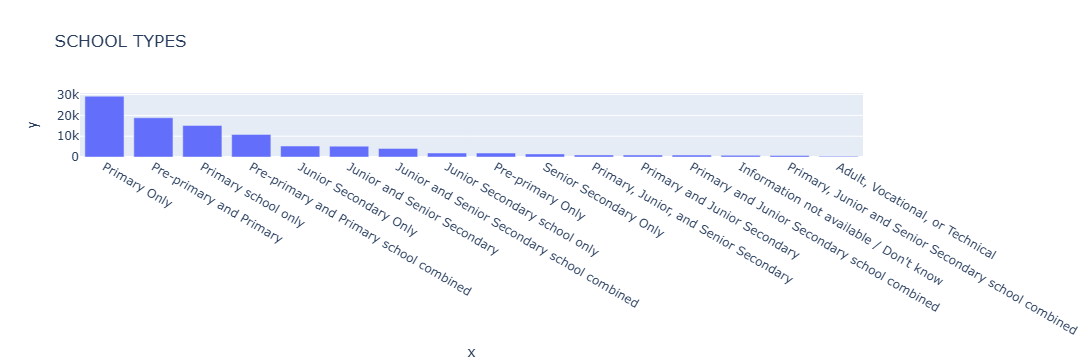

In [165]:
# Visualization 

fig = px.bar(
    facility_type,
    x=facility_type.index,
    y=facility_type.values,
    title="SCHOOL TYPES"
)

fig.show()

In [166]:
# Part 3: Exploratory Data Analysis (EDA)
# Answer the following key questions using analysis and supporting visualizations:

#2. What percentage of schools have:
#        Improved water supply?

water_supply_pct = (
    df["Improved_Water_Supply"]
    .mean() * 100
)   

print(water_supply_pct)

37.93973669007875


In [167]:
# Part 3: Exploratory Data Analysis (EDA)
# Answer the following key questions using analysis and supporting visualizations:

# 2. What percentage of schools have:
#        Improved sanitation?

sanitation_perctg = (
    df["Improved_Sanitation"]
    .mean() * 100
)

print(sanitation_perctg)

45.95052043743095


In [168]:
# Part 3: Exploratory Data Analysis (EDA)
# Answer the following key questions using analysis and supporting visualizations:
# 2. What percentage of schools have:
#              Electricity?

electricity_perctg = (
    df["PHCN_Electricity"]
    .mean() * 100
)

print(electricity_perctg)

24.987077746358967


In [169]:
# Part 3: Exploratory Data Analysis (EDA)
# Answer the following key questions using analysis and supporting visualizations:
# 3. What is the average number of:
#         Students per school?
        
average_student = df["Total_Students_Number"].mean()

print(average_student)

329.4115763122422


In [170]:
# Part 3: Exploratory Data Analysis (EDA)
# Answer the following key questions using analysis and supporting visualizations:
# 3. What is the average number of:
#         Teachers per school?

average_teacher = df["Total_Teachers"].mean()

print(average_teacher)

11.517782034520154


In [171]:
# Part 3: Exploratory Data Analysis (EDA)
# Answer the following key questions using analysis and supporting visualizations:
# 4. Compare public vs private schools in terms of: Student population

df.groupby("Management")["Total_Students"].mean()


Management
faith_based    298.650750
none           215.946903
private        223.350627
public         387.514173
Name: Total_Students, dtype: float64

In [172]:
# Part 3: Exploratory Data Analysis (EDA)
# Answer the following key questions using analysis and supporting visualizations:
# 4. Compare public vs private schools in terms of:Teacher count

df.groupby("Management")["Total_Teachers"].mean()

Management
faith_based    14.258527
none            6.955752
private        12.738139
public         11.146599
Name: Total_Teachers, dtype: float64

In [173]:
# Part 3: Exploratory Data Analysis (EDA)
# Answer the following key questions using analysis and supporting visualizations:
# 4. Compare public vs private schools in terms of: Infrastructure availability

df.groupby("Management")[
[
"PHCN_Electricity",
"Improved_Water_Supply",
"Improved_Sanitation"
]
].mean()*100

,PHCN_Electricity,Improved_Water_Supply,Improved_Sanitation
Management,,,
faith_based,52.864939,64.733970,74.215553
none,5.752212,4.424779,5.309735
private,51.552555,56.976856,71.162006
public,17.280777,32.344724,38.668591


In [174]:
5. # Identify states or LGAs with: The highest number of schools
    
df["Unique_LGA"].value_counts().head(10)

Unique_LGA
ogun_ifo                      566
kaduna_chikun                 446
kaduna_kachia                 334
kaduna_igabi                  331
benue_buruku                  328
delta_uvwie                   328
lagos_kosofe                  324
ogun_ado_odo_ota              320
fct_municipal_area_council    319
fct_bwari                     317
Name: count, dtype: int64

In [175]:
# 5. Identify states or LGAs with: The lowest access to electricity

df.groupby("Unique_LGA")['PHCN_Electricity'].mean().sort_values().tail(10)

Unique_LGA
lagos_ifako_ijaye             0.791667
fct_municipal_area_council    0.793103
cross_river_calabar_south     0.796296
anambra_onitsha_north         0.807692
delta_uvwie                   0.823171
jigawa_hadejia                0.847458
lagos_ikeja                   0.852273
lagos_ajeromi_ifelodun        0.875000
lagos_shomolu                 0.887097
lagos_kosofe                  0.907407
Name: PHCN_Electricity, dtype: float64

In [176]:
# 5. Identify states or LGAs with: The lowest access to sanitation

df.groupby("Unique_LGA")["Improved_Sanitation"].mean().sort_values().tail(10)

Unique_LGA
akwa_ibom_ika            0.888889
lagos_agege              0.897196
kaduna_kaduna_south      0.908696
borno_maiduguri          0.912500
anambra_onitsha_north    0.913462
katsina_daura            0.917808
katsina_matazu           0.923077
lagos_ifako_ijaye        0.927083
lagos_kosofe             0.956790
sokoto_sokoto_south      1.000000
Name: Improved_Sanitation, dtype: float64

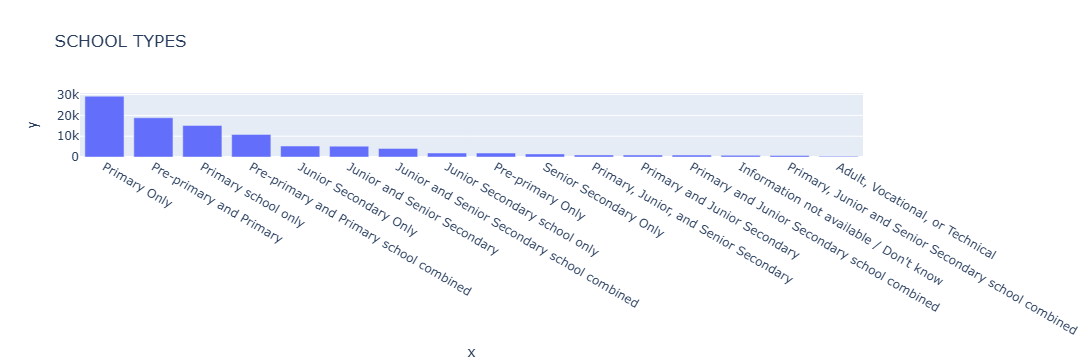

In [177]:
# Part 4: Data Visualization
# Create clear and well-labeled visualizations using Plotly. 
# At minimum, include:
#     Bar chart of school types

fig = px.bar(
    facility_type,
    x=facility_type.index,
    y=facility_type.values,
    title="SCHOOL TYPES"
)

fig.show()


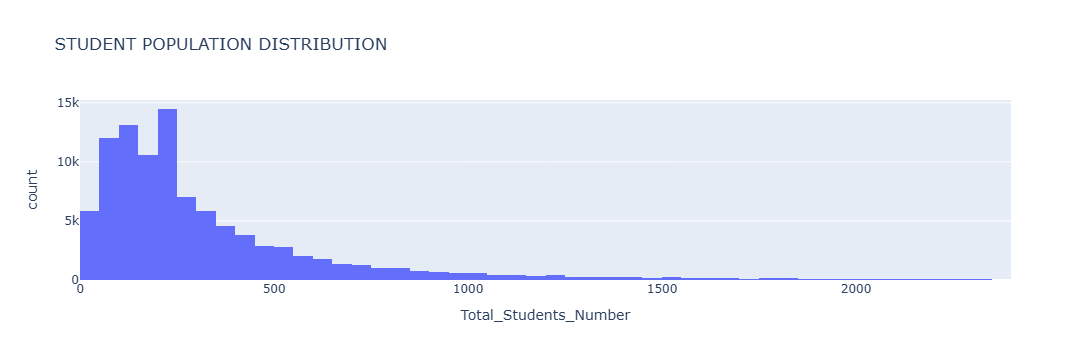

In [178]:
# Part 4: Data Visualization
# Create clear and well-labeled visualizations using Plotly. 
# At minimum, include:
#      Histogram of student population

fig = px.histogram(df, 
    x='Total_Students_Number',
    nbins=50,
    title="STUDENT POPULATION DISTRIBUTION"
)

fig.show()

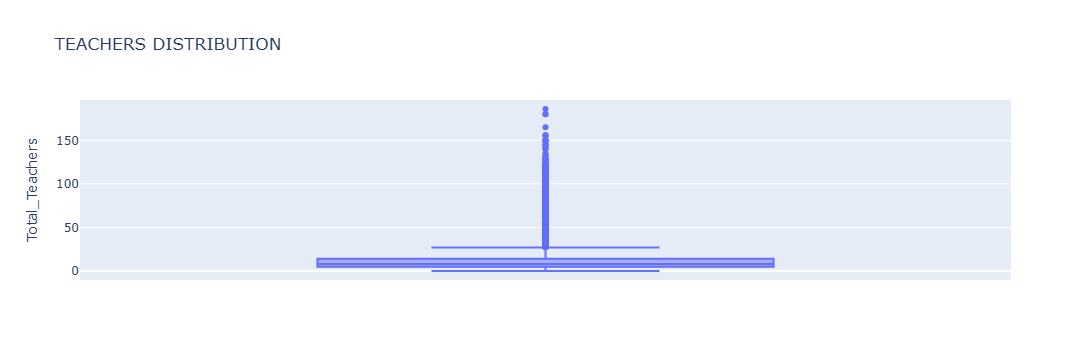

In [179]:
# Part 4: Data Visualization
# Create clear and well-labeled visualizations using Plotly. 
# At minimum, include:

#      Boxplot of teacher distribution
  
fig = px.box(
    df,
    y='Total_Teachers',
    title= "TEACHERS DISTRIBUTION"
)

fig.show()

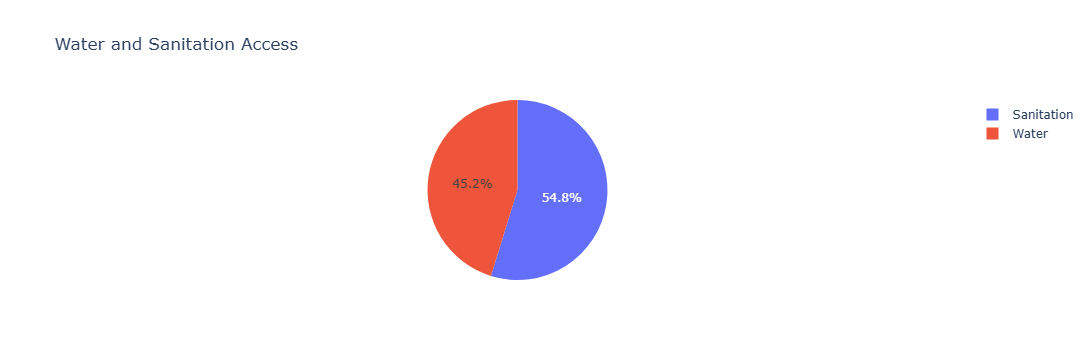

In [180]:
# Part 4: Data Visualization
# Create clear and well-labeled visualizations using Plotly. 
# At minimum, include:
#     Pie chart of water and sanitation access

access = pd.DataFrame({
    'Category':['Water','Sanitation'],
    'Percentage':[water_supply_pct,sanitation_perctg]
})

fig = px.pie(
    access,
    values='Percentage',
    names='Category',
    title='Water and Sanitation Access'
)

fig.show()
  


C:\Users\hp\AppData\Local\Temp\ipykernel_19120\1287222232.py:6: DeprecationWarning: *scatter_mapbox* is deprecated! Use *scatter_map* instead. Learn more at: https://plotly.com/python/mapbox-to-maplibre/
  fig6 = px.scatter_mapbox(


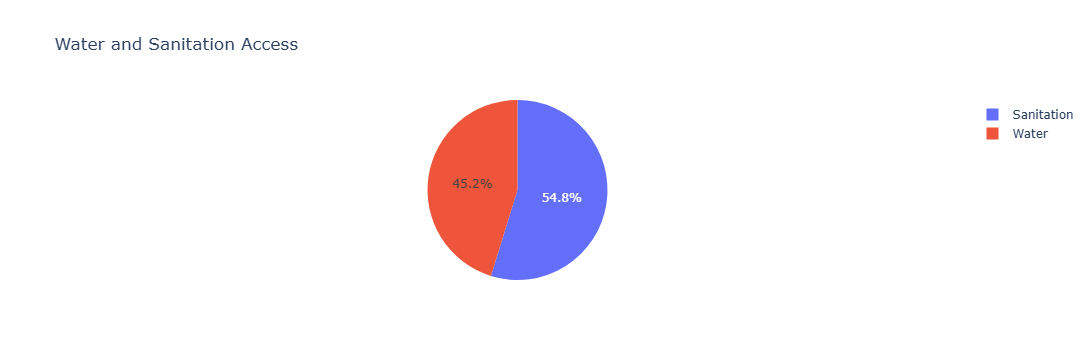

In [181]:
# Part 4: Data Visualization
# Create clear and well-labeled visualizations using Plotly. 
# At minimum, include:
#     Map visualization using latitude and longitude

fig6 = px.scatter_mapbox(
    df,
    lat="Latitude",
    lon="Longitude",
    hover_name="Facility_Name",
    zoom=5,
    height=700
)

fig6.update_layout(
    mapbox_style="open-street-map"
)

fig.show()


In [182]:
df.to_csv("data/Cleaned_educational_facilities_in_nigeria.csv", index=False)

Part 6: Final Insights & Recommendations
Write a short report answering:

What major problems exist in Nigeria’s educational infrastructure?

1. Many schools in Nigeria still lack reliable electricity, improved sanitation, safe water supply. 
2. Public schools generally have larger student populations and higher student-teacher ratios
3. Educational facilities are unevenly distributed across states and LGAs.


Which regions need the most attention?

1. States with the lowest electricity access
2. States with poor sanitation coverage
3. LGAs with high student-teacher ratios
4. Areas with overcrowded schools

How can governments or NGOs use this data for decision-making?

Recommendations for Government

1. Invest in rural school infrastructure.
2. Improve electricity access through solar-powered solutions.
3. Expand water and sanitation facilities.
   
Recommendations for NGOs

1. Target underserved LGAs using geographic data.
2. Fund boreholes, toilets, and classroom construction.
3. Support teacher recruitment and training.

These actions can significantly improve educational access, learning conditions, and overall educational outcomes across Nigeria.


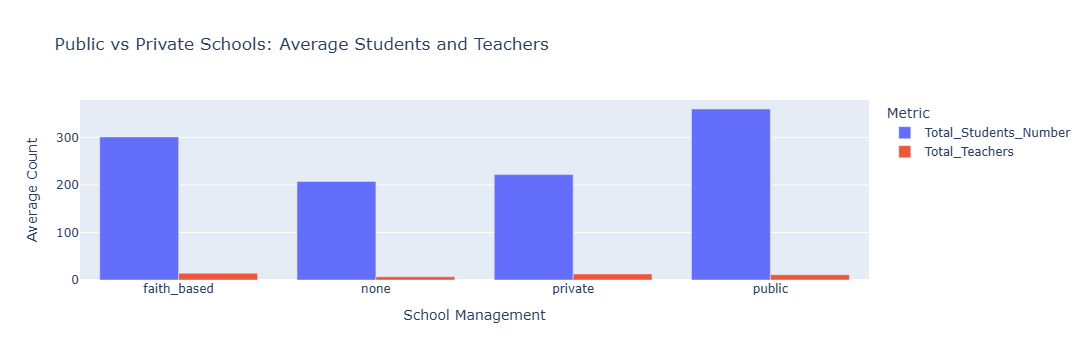

In [183]:
# Group by management type (Public/Private)
comparison = (
    df.groupby('Management')[['Total_Students_Number', 'Total_Teachers']]
      .mean()
      .reset_index()
)
# Create bar chart
fig = px.bar(
    comparison,
    x='Management',
    y=['Total_Students_Number', 'Total_Teachers'],
    barmode='group',
    title='Public vs Private Schools: Average Students and Teachers',
    labels={
        'Management' : 'School Management',
        'value': 'Average Count',
        'variable': 'Metric'
    }
)

fig.show()


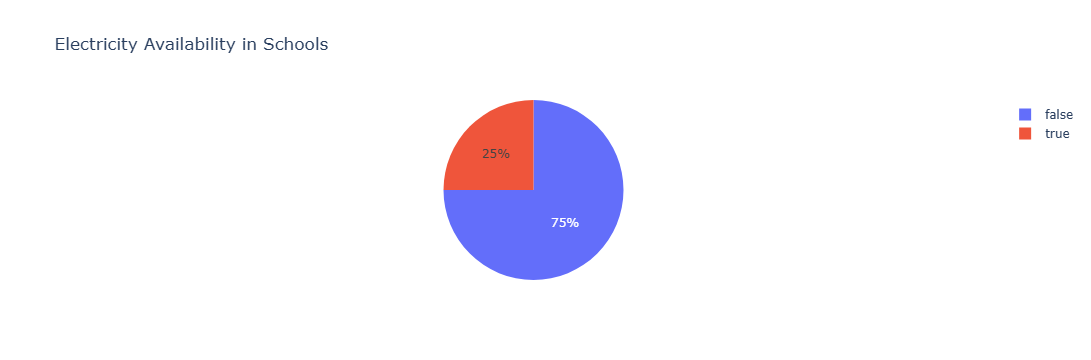

In [184]:
#Electricity availability
electricity_counts = df['PHCN_Electricity'].value_counts().reset_index()
electricity_counts.columns = ['Electricity', 'Count']

fig = px.pie(
    electricity_counts,
    names='Electricity',
    values='Count',
    title='Electricity Availability in Schools'
)

fig.show()